In [1]:
%load_ext autoreload
%autoreload 2

from distutils.dist import Distribution

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow_probability.substrates import jax as tfp

import qdots_qll
from qdots_qll.distributions import (
    Distribution,
    normalize_log_weights,
    update_log_weights,
)
from qdots_qll.exp_design import RandExpDesignGAME
from qdots_qll.models.single_dot_weak_coupling_GAME import (
    Data,
    ExperimentSingleDotWeakCouplingGAME,
    SingleDotWeakCouplingGAME,
)
from qdots_qll.resamplers import LiuWestResampler, MetropolisSampler


/tmp/ipykernel_83701/1243592004.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
seed = 0
key = jax.random.key(seed=seed)
key, subkey = jax.random.split(key)


In [130]:
model = SingleDotWeakCouplingGAME()

boundaries = jnp.array(
    [
        [0.1, 0.5],
        [0.1, 0.5],
        [0.01, 0.2],
        [-0.5, -0.01],
    ]
)


loc = boundaries.mean(axis=1)
scale = boundaries.std(axis=1)


truncated_norm = tfp.distributions.TruncatedNormal(
    loc=loc, scale=scale, low=boundaries[:, 0], high=boundaries[:, 1]
)

no_particles = 500
init_particles_locations = truncated_norm.sample(
    seed=subkey, sample_shape=(no_particles,)
)
weights = jnp.ones(no_particles) / no_particles

dist = Distribution(particles_locations=init_particles_locations, weights=weights)

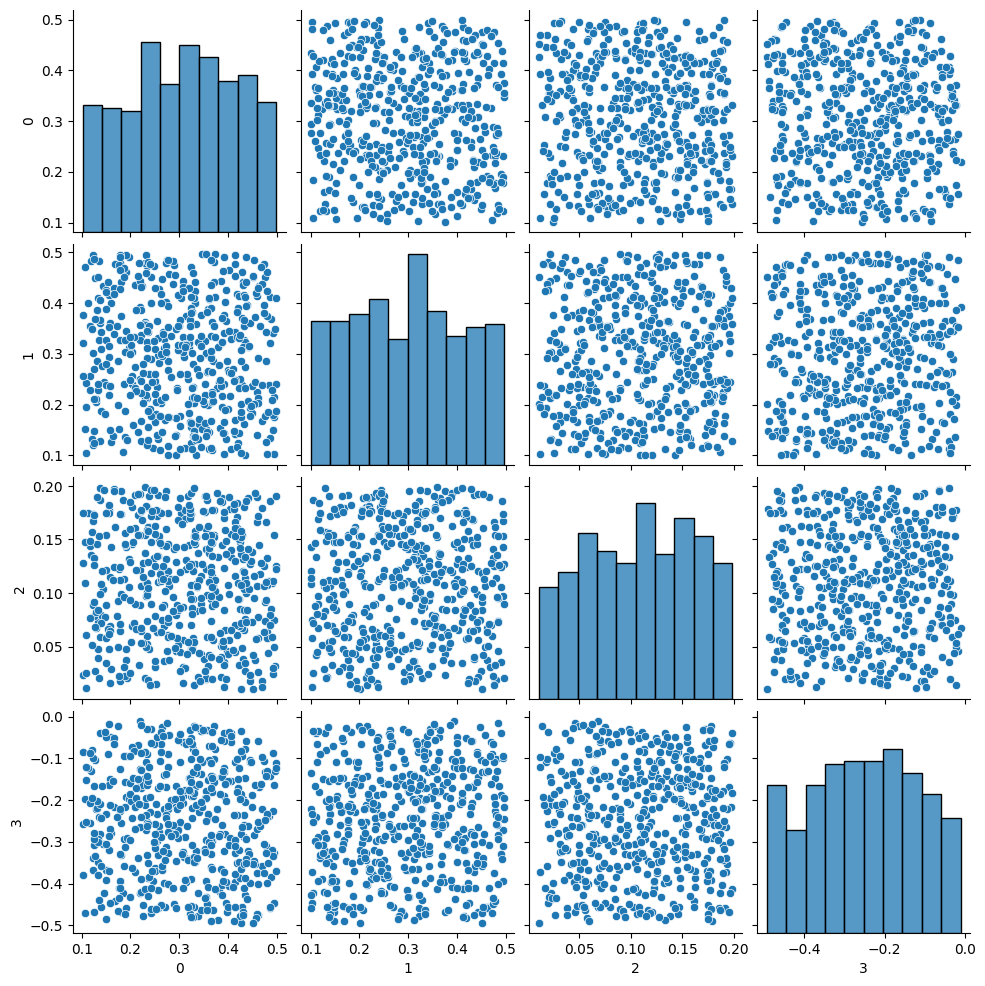

In [131]:
df = pd.DataFrame(np.array(dist.particles_locations))
sns.pairplot(data=df)

In [132]:
key, subkey = jax.random.split(key)
e1 = ExperimentSingleDotWeakCouplingGAME(23.0, 0, 1)
o1 = model.measure_one_experiment(subkey, e1)
d1 = Data(e1, o1)

key, subkey = jax.random.split(key)
e2 = RandExpDesignGAME().generate_experiment(subkey)
key, subkey = jax.random.split(key)

o2 = model.measure_one_experiment(subkey, e2)
d2 = Data(e2, o2)

total_data = d1.append(d2)

In [133]:
# from qdots_qll.smc import do_not_resample
from jaxtyping import Array

In [134]:
from qdots_qll.smc import SMCUpdater

exp_design = RandExpDesignGAME()
# resampler = MetropolisSampler(boundaries=boundaries, model=model)
resampler = LiuWestResampler(boundaries=boundaries)


smc = SMCUpdater(model=model, exp_design=exp_design, resampler=resampler)

In [135]:
model.true_parameters

Array([ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482], dtype=float32)

In [144]:
# iteration = 0
# data = d1  # !REMEMBER to discard the first data

for _ in range(40):
    key, dist, data = smc.step(iteration=iteration, key=key, dist=dist, data=data)
    iteration = iteration + 1

In [145]:
dist.ev()

Array([ 0.42320532,  0.2855158 ,  0.10038055, -0.3681611 ], dtype=float32)

In [146]:
resampler.resample(subkey, dist, data)

Distribution(
  no_rv=4,
  no_particles=500,
  particles_locations=f32[500,4],
  log_weights=f32[500],
  weights=f32[500],
  ESS=f32[]
)

In [154]:
import matplotlib.pyplot as plt

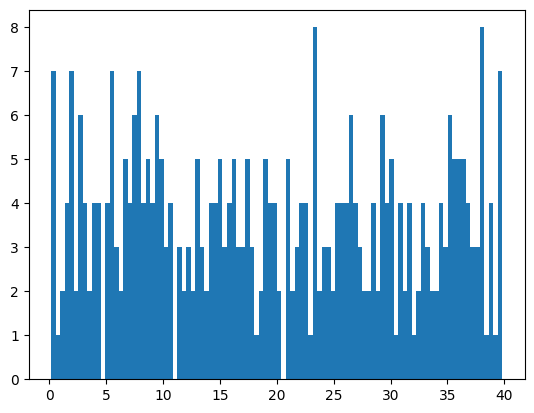

In [157]:
plt.hist(np.array(data.experiment.time), bins=100)
plt.show()